<a href="https://colab.research.google.com/github/geun-hyoung/python-textmining-understanding_shs/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setting

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# install library
!pip install nltk
!pip install -U pandas-profiling
!pip install pydantic
!pip install umap-learn
!pip install factor_analyzer
!pip install typing-extensions --upgrade
!pip install kneed
!pip install spacy

In [38]:
import re
import string
from string import punctuation
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from collections import Counter

from scipy.sparse import csr_matrix

from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA, LatentDirichletAllocation, NMF,TruncatedSVD
from sklearn.feature_selection import chi2, f_classif, SelectKBest
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer, normalize

import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.lang.en import English

import seaborn as sns

from wordcloud import WordCloud

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import TreebankWordTokenizer, word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

from textblob import Word

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [39]:
origin_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/train_data.csv")
print("초기 문서 수 :", origin_data.shape[0])

초기 문서 수 : 3840


In [40]:
print("데이터 열", origin_data.columns)

데이터 열 Index(['Publication Type', 'Authors', 'Book Authors', 'Book Editors',
       'Book Group Authors', 'Author Full Names', 'Book Author Full Names',
       'Group Authors', 'Article Title', 'Source Title', 'Book Series Title',
       'Book Series Subtitle', 'Language', 'Document Type', 'Conference Title',
       'Conference Date', 'Conference Location', 'Conference Sponsor',
       'Conference Host', 'Author Keywords', 'Keywords Plus', 'Abstract',
       'Addresses', 'Affiliations', 'Reprint Addresses', 'Email Addresses',
       'Researcher Ids', 'ORCIDs', 'Funding Orgs', 'Funding Name Preferred',
       'Funding Text', 'Cited References', 'Cited Reference Count',
       'Times Cited, WoS Core', 'Times Cited, All Databases',
       '180 Day Usage Count', 'Since 2013 Usage Count', 'Publisher',
       'Publisher City', 'Publisher Address', 'ISSN', 'eISSN', 'ISBN',
       'Journal Abbreviation', 'Journal ISO Abbreviation', 'Publication Date',
       'Publication Year', 'Volume', 'Issue

## STEP 1 : Data Cleaning


In [41]:
# 중복 제거
origin_data.drop_duplicates(subset=['Article Title', 'Abstract'], inplace=True)
print("Document 수 :", origin_data.shape[0])

Document 수 : 3837


In [42]:
# 결측치 제거
origin_data.dropna(subset=['Abstract', 'Article Title'], inplace=True)
print("Document 수 :", origin_data.shape[0])

Document 수 : 3833


In [43]:
# data transformation
def combine_columns(*kwargs):
    result = ""

    for sth in kwargs:
        if not pd.isna(sth):
            result += " " + str(sth)

    return result

origin_data["text"] = origin_data.apply(lambda x: combine_columns(x['Article Title'], x['Abstract'], x['Author Keywords']), axis=1)
df = origin_data.loc[:, ['text', 'Article Title']]

print("Data Transformation 후 Document 수 :", df.shape[0])

Data Transformation 후 Document 수 : 3833


### Data preprocessing

In [44]:
custom_nolema = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized_rule_1(lemmatization).csv")
custom_stopwords = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized_rule_2(stopwords).csv")
# custom_document = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/extract_del_document.csv")

custom_nolema = list(custom_nolema['nolema'])
stop_words = stop_words.union(list(custom_stopwords['Stopwords']))
# del_titles = list(custom_document['Article Title'])

#print(len(del_titles))
punctuations = list(punctuation)

In [45]:
import re

def preprocess_text(text):
    # tokenization
    tokens = word_tokenize(text)

    # check specific problem(i.e., do not lemmatize)
    changed, filtered_tokens = [], []
    wordnet_lemmatizer = WordNetLemmatizer()

    for word in tokens:
        # remove numbers
        word = re.sub(r'\d+', '', word)

        # remove words with length less than 2
        if len(word) < 2:
            continue

        temp_word = word.lower()

        # lemmatization using TextBlob
        lemma_word = Word(temp_word).lemmatize() if temp_word not in custom_nolema else temp_word

        if temp_word != lemma_word:
            changed.append({temp_word: lemma_word})

        filtered_tokens.append(lemma_word)

    filtered_tokens = [word for word in filtered_tokens if word not in stop_words and word not in punctuations]
    processed_text = ' '.join([token for token in filtered_tokens])

    return processed_text, changed

df['corpus'], df['lemma_pairs'] = zip(*df['text'].apply(preprocess_text))
df.drop(columns=['text'], inplace=True)
df.head()

,Article Title,corpus,lemma_pairs
0,HyDSMaaS: A Hybrid Communication Infrastructur...,hydsmaas hybrid communication infrastructure l...,"[{'as': 'a'}, {'problems': 'problem'}, {'consu..."
1,Optimal operating scheme of neighborhood energ...,optimal operating scheme neighborhood energy s...,"[{'communities': 'community'}, {'cities': 'cit..."
2,A Smart Optimization of Fault Diagnosis in Ele...,smart optimization fault diagnosis electrical ...,"[{'demands': 'demand'}, {'years': 'year'}, {'u..."
3,IIoT: Traffic Data Flow Analysis and Modeling ...,iiot traffic data flow analysis modeling exper...,"[{'devices': 'device'}, {'things': 'thing'}, {..."
4,Privacy-Preserved Behavior Analysis and Fall D...,privacy-preserved behavior analysis fall detec...,"[{'sensors': 'sensor'}, {'sequences': 'sequenc..."


In [46]:
df = df.loc[:, ['corpus', 'Article Title']]
df.drop(df[(df['corpus'] == "")].index, inplace=True) # corpus 남아있지 않은 row 삭제

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print("전처리 후 Document 갯수:",tfidf_matrix.shape[0])
print("전처리 후 초기 word-feature 갯수:",tfidf_matrix.shape[1])

전처리 후 Document 갯수: 3833
전처리 후 초기 word-feature 갯수: 16274


##### Make customized rules : do not lemmatize “glasses” to “glass : test data(pilot study) 시에만 사용



In [ ]:
# find do not lemmatize
check_list = df.loc[:, ['lemma_pairs']]
combined_list = check_list['lemma_pairs'].sum()

keys, values = [], []

for d in combined_list:
    for key, value in d.items():
        keys.append(key)
        values.append(value)

checks = pd.DataFrame({'Key': keys, 'Value': values})
checks.drop_duplicates(subset=['Key'], inplace=True)
checks.drop_duplicates(subset=['Value'], inplace=True)

checks

In [ ]:
def check_meaning(row):
    key_word = Word(row['Key']).definitions
    value_word = Word(row['Value']).definitions

    if key_word and value_word:
        if key_word[0] != value_word[0]:
            return (True, f"'{row['Key']}': {key_word[0]}", f"'{row['Value']}': {value_word[0]}")

    return (False, None, None)

# 각 행에 대해 check_meaning 함수를 적용합니다.
checks['is_different'], checks['key_def'], checks['value_def'] = zip(*checks.apply(check_meaning, axis=1))

# 'is_different' 열이 True인 행만 선택하여 새로운 DataFrame으로 저장합니다.
different_checks = checks[checks['is_different']]

# 새로운 DataFrame을 CSV 파일로 저장합니다.
different_checks.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized(not_lemmatize).csv', index=False)

In [ ]:
different_checks

## STEP 2 : Word-featuring

### 1. Deciding on the number of keywords to be selected from each item

In [47]:
# visualization function
def plot_keywords(x, y, y_label, title):

    plt.style.use('seaborn-whitegrid')
    plt.figure(figsize=(10,6))

    plt.plot(x, y,  marker='o', color = 'b')

    plt.gca().invert_xaxis()

    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.gca().set_facecolor('lightgray')
    plt.grid(color='white', linestyle='-', linewidth=1)

    k_formatter = FuncFormatter(lambda x, pos: f'K{x}')
    plt.gca().xaxis.set_major_formatter(k_formatter)

    plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

    plt.xlabel('Number of selected top keywords from each data')
    plt.ylabel(y_label)

    for i in [3, 4, 5, 6]:
        if i in x:
            index = x.index(i)
            plt.plot(i, y[index], marker='o', color='y')

    plt.title(title)
    plt.show()

keyword_counts = list(range(20, 1, -1))
tfidf_matrix_transposed = tfidf_matrix.toarray()

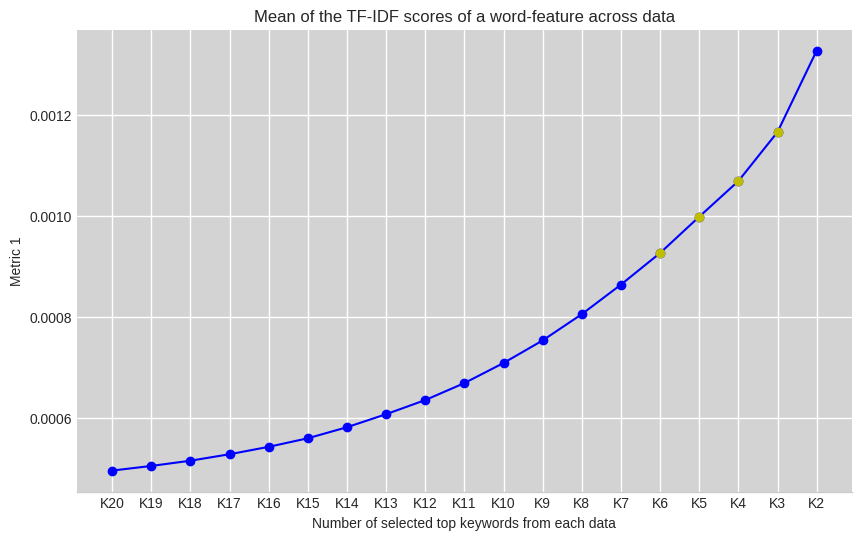

In [48]:
mean_tfidf_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])
    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_tfidf_scores = tfidf_matrix[:, keyword_indices].toarray()

    # TF-IDF score 평균 계산
    mean_tfidf_score = np.mean(keyword_tfidf_scores)
    mean_tfidf_scores.append(mean_tfidf_score)

plot_keywords(keyword_counts, mean_tfidf_scores, 'Metric 1',  'Mean of the TF-IDF scores of a word-feature across data')

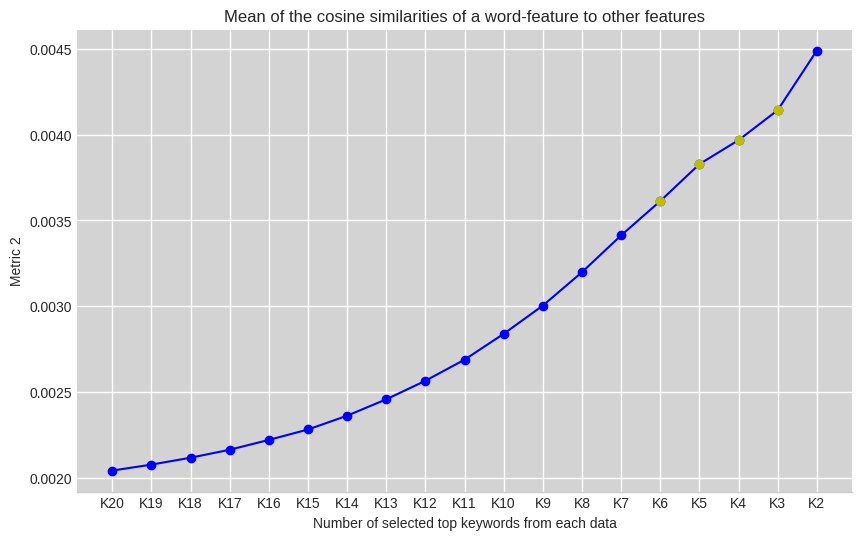

In [49]:
mean_cosine_similarities = []

for num_keywords in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-num_keywords:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_matrix = tfidf_matrix[:, keyword_indices].T
    cosine_similarities = cosine_similarity(keyword_matrix)

    mean_cosine_similarity = np.mean(cosine_similarities)
    mean_cosine_similarities.append(mean_cosine_similarity)

plot_keywords(keyword_counts, mean_cosine_similarities,'Metric 2', 'Mean of the cosine similarities of a word-feature to other features')

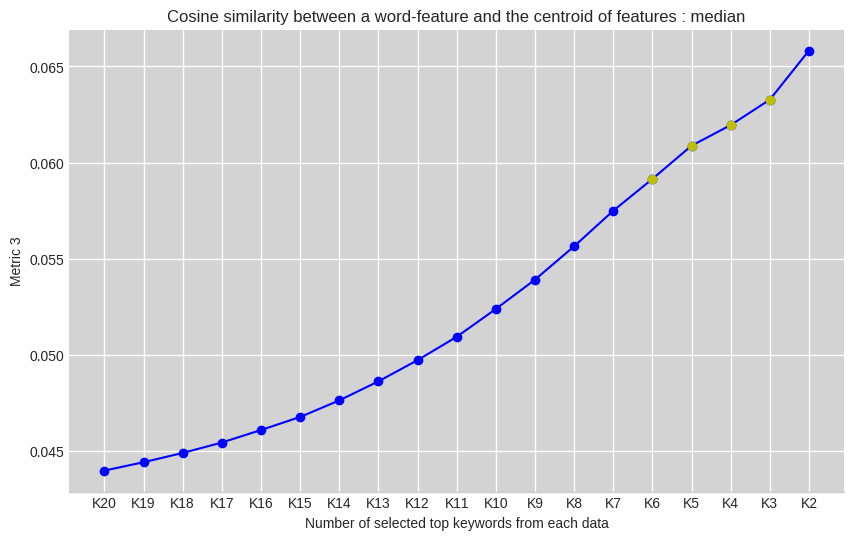

In [50]:
median_cosine_similarities = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_matrix = tfidf_matrix[:, keyword_indices]

    keyword_matrix = keyword_matrix.T.toarray()

    centroid = np.mean(keyword_matrix, axis=0)
    centroid = np.asarray(centroid).reshape(1, -1)

    cosine_similarities = []

    for idx in range(keyword_matrix.shape[0]):
        word_vector = keyword_matrix[idx, :]
        word_vector = np.asarray(word_vector).reshape(1, -1)
        cosine_similarity_value = cosine_similarity(word_vector, centroid)
        cosine_similarities.append(cosine_similarity_value[0][0])


    mean_cosine_similarity = np.mean(cosine_similarities)
    median_cosine_similarities.append(mean_cosine_similarity)

plot_keywords(keyword_counts, median_cosine_similarities, "Metric 3", "Cosine similarity between a word-feature and the centroid of features : median")

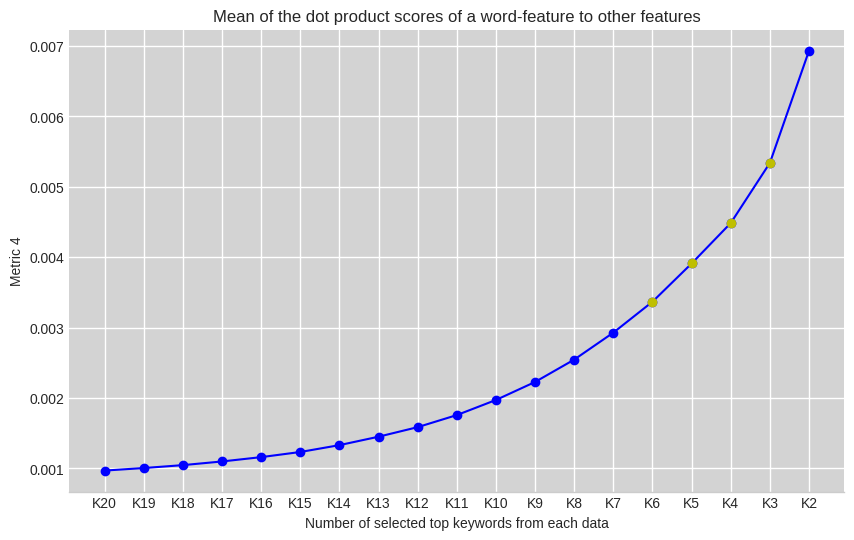

In [51]:
mean_dot_product_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))

    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_tfidf_scores = tfidf_matrix[:, keyword_indices].toarray()
    dot_product_scores = np.dot(keyword_tfidf_scores.T, keyword_tfidf_scores)

    mean_dot_product_score = np.mean(dot_product_scores)
    mean_dot_product_scores.append(mean_dot_product_score)

plot_keywords(keyword_counts, mean_dot_product_scores,"Metric 4", "Mean of the dot product scores of a word-feature to other features")

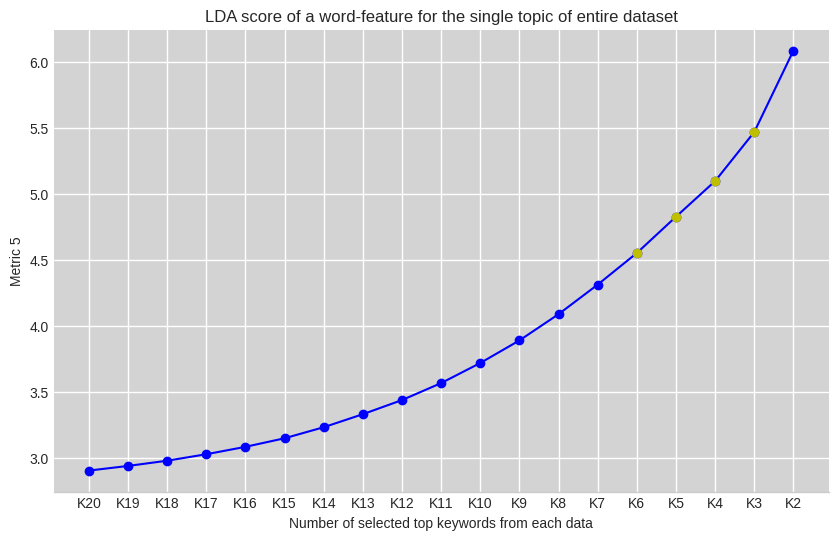

In [52]:
mean_lda_scores = []

for count in keyword_counts:
    top_keywords = []

    for doc_idx in range(len(df)):
        tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]
        top_indices = np.argsort(tfidf_scores)[-count:]
        top_keywords.extend([feature_names[idx] for idx in top_indices])

    top_keywords = list(set(top_keywords))
    keyword_indices = [np.where(np.array(feature_names) == keyword)[0][0] for keyword in top_keywords]
    keyword_matrix = tfidf_matrix[:, keyword_indices].toarray()

    num_topics = 1
    lda_model = LatentDirichletAllocation(n_components=num_topics)
    lda_model.fit(keyword_matrix)

    lda_scores = lda_model.components_

    mean_lda_score = np.mean(lda_scores)
    mean_lda_scores.append(mean_lda_score)

plot_keywords(keyword_counts, mean_lda_scores,"Metric 5", "LDA score of a word-feature for the single topic of entire dataset")

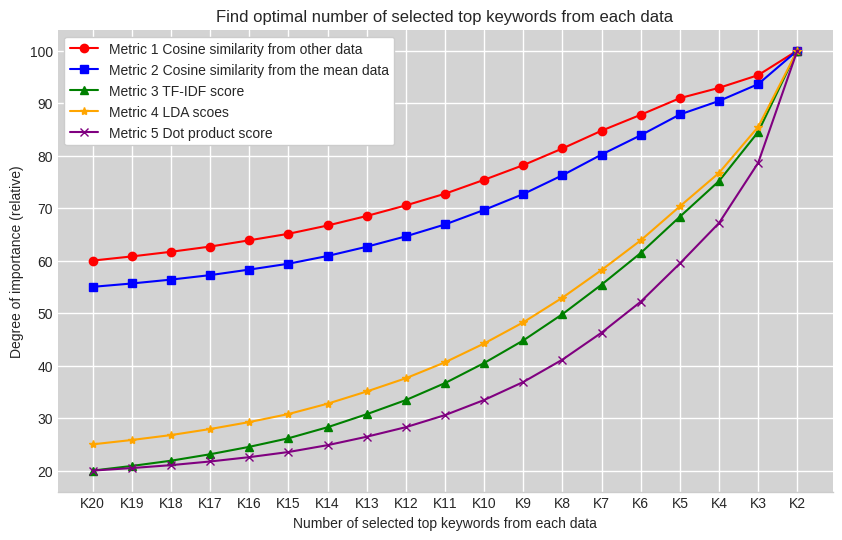

In [53]:
metric1_values = median_cosine_similarities
metric2_values = mean_cosine_similarities
metric3_values = mean_tfidf_scores
metric4_values = mean_lda_scores
metric5_values = mean_dot_product_scores

metric1_normalized = (metric1_values - np.min(metric1_values)) / (np.max(metric1_values) - np.min(metric1_values)) * 40 + 60
metric2_normalized = (metric2_values - np.min(metric2_values)) / (np.max(metric2_values) - np.min(metric2_values)) * 45 + 55
metric3_normalized = (metric3_values - np.min(metric3_values)) / (np.max(metric3_values) - np.min(metric3_values)) * 80 + 20
metric4_normalized = (metric4_values - np.min(metric4_values)) / (np.max(metric4_values) - np.min(metric4_values)) * 75 + 25
metric5_normalized = (metric5_values - np.min(metric5_values)) / (np.max(metric5_values) - np.min(metric5_values)) * 80 + 20

plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(10,6))

plt.gca().invert_xaxis()

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.gca().set_facecolor('lightgray')

plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

k_formatter = FuncFormatter(lambda x, pos: f'K{x}')

plt.gca().xaxis.set_major_formatter(k_formatter)
plt.grid(color='white', linestyle='-', linewidth=1)
plt.xlabel('Number of selected top keywords from each data')
plt.ylabel('Degree of importance (relative)')

plt.plot(keyword_counts, metric1_normalized, marker='o', label='Metric 1 Cosine similarity from other data', color='red')
plt.plot(keyword_counts, metric2_normalized, marker='s', label='Metric 2 Cosine similarity from the mean data', color='blue')
plt.plot(keyword_counts, metric3_normalized, marker='^', label='Metric 3 TF-IDF score', color='green')
plt.plot(keyword_counts, metric4_normalized, marker='*', label='Metric 4 LDA scoes', color='orange')
plt.plot(keyword_counts, metric5_normalized, marker='x', label='Metric 5 Dot product score', color='purple')

plt.xlabel('Number of selected top keywords from each data')
plt.ylabel('Degree of importance (relative)')
plt.title('Find optimal number of selected top keywords from each data')
plt.legend(frameon = True, framealpha=1)

plt.show()

In [54]:
# Items 당 상위 4개의 단어 선택 - Type 3 제거
top_keywords_per_document = []
feature_names = tfidf_vectorizer.get_feature_names_out()

for i in range(len(df)):
    tfidf_scores = zip(feature_names, tfidf_matrix[i].toarray()[0])
    sorted_tfidf_scores = sorted(tfidf_scores,key=lambda x: x[1], reverse=True)

    top_keywords_per_document.append([keyword for keyword,_ in sorted_tfidf_scores[:4]])

# 전체 데이터셋에서 적어도 2번 이상 나온 키워드 추출하기 - Type 1 제거
all_keywords=[keyword for document in top_keywords_per_document for keyword in document]
selected_keywords=list(set(keyword for keyword in all_keywords if all_keywords.count(keyword) >=2))

vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 3833
현재 word-feature 갯수: 1820


### 2. Clustering based on Gaussian mixture model (GMM)

In [55]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)

tfidf_matrix = vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T.toarray()

feature_names = vectorizer.get_feature_names_out()

In [56]:
print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 3833
현재 word-feature 갯수: 1820


In [60]:
from collections import defaultdict

tfidf_matrix_transposed = tfidf_matrix.T.toarray()

keyword_frequency = defaultdict(int)

# GMM based Clustering
for i in range(10):

    gmm = GaussianMixture(n_components=100, covariance_type='diag')
    gmm.fit(tfidf_matrix_transposed)

    cluster_labels = gmm.predict(tfidf_matrix_transposed)

    df_clustered_keywords = pd.DataFrame(feature_names, columns=['keyword'])
    df_clustered_keywords['cluster'] = cluster_labels

    cluster_counts = df_clustered_keywords['cluster'].value_counts()
    max_data_pointer_cluster_labels = cluster_counts.nlargest(1).index.tolist()
    max_data_pointer_cluster = df_clustered_keywords[df_clustered_keywords['cluster'].isin(max_data_pointer_cluster_labels)]['keyword'].values.tolist()

    for keyword in max_data_pointer_cluster:
        keyword_frequency[keyword] += 1

    print(f"{i + 1}번째 시행 클러스터 속 데이터 갯수:", len(max_data_pointer_cluster))

1번째 시행 클러스터 속 데이터 갯수: 1144
2번째 시행 클러스터 속 데이터 갯수: 1684
3번째 시행 클러스터 속 데이터 갯수: 1173
4번째 시행 클러스터 속 데이터 갯수: 1148
5번째 시행 클러스터 속 데이터 갯수: 1082
6번째 시행 클러스터 속 데이터 갯수: 1137
7번째 시행 클러스터 속 데이터 갯수: 926
8번째 시행 클러스터 속 데이터 갯수: 958
9번째 시행 클러스터 속 데이터 갯수: 1096
10번째 시행 클러스터 속 데이터 갯수: 1069


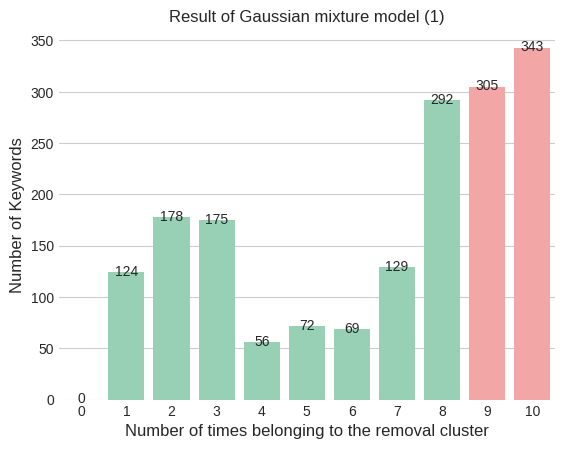

In [61]:
x = list(range(0, 11))
counts = [len([k for k, v in keyword_frequency.items() if (v >= i) & (v<i+1)]) for i in x]

palette = ["#8fd9b6" if i < 9 else "#ff9999" for i in x]

barplot = sns.barplot(x=x, y=counts, palette=palette)

for idx, val in enumerate(counts):
    barplot.text(idx, val+0.5, val, ha='center', va='center')

plt.title('Result of Gaussian mixture model (1)', fontsize=12)
plt.xlabel('Number of times belonging to the removal cluster', fontsize=12)
plt.ylabel('Number of Keywords', fontsize=12)

sns.despine(left=True, bottom=True)

plt.show()

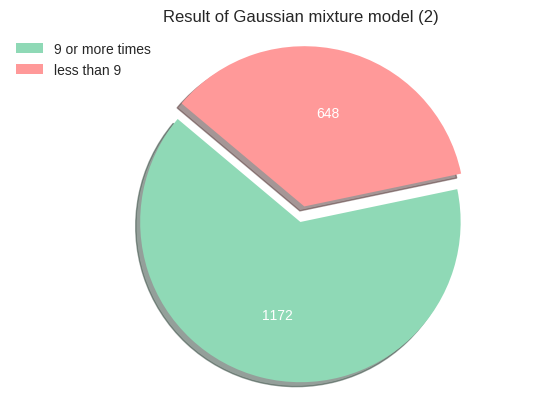

In [62]:
x = [j for j in range(0, 11)]
counts = []

for i in range(0, 11):
    counts.append(len([k for k, v in keyword_frequency.items() if (v >= i) & (v<i+1)]))

counts[0] = len(selected_keywords) - len(keyword_frequency)

counts_less_than_9 = sum(counts[:9])
counts_more_than_9 = sum(counts[9:])

sizes = [counts_less_than_9, counts_more_than_9]
colors = ['#8fd9b6', '#ff9999']

fig, ax = plt.subplots()
labels = ['9 or more times', 'less than 9']
patches, texts, autotexts = ax.pie(sizes, colors=colors, autopct=lambda p: '{:.0f}'.format(p * sum(sizes) / 100), startangle=140, explode=(0.1, 0), shadow=True)

ax.axis('equal')

for autotext in autotexts:
    autotext.set_color('white')

plt.title('Result of Gaussian mixture model (2)')

ax.legend(patches, labels, loc='upper left', bbox_to_anchor=(-0.1, 1))

plt.show()

In [63]:
temp_keywords = [k for k, v in keyword_frequency.items() if v >= 9]
core_keywords = [keyword for keyword in selected_keywords if keyword not in temp_keywords]

In [64]:
vectorizer = TfidfVectorizer(vocabulary=core_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

print("Core-word feature Document 갯수:",tfidf_matrix.shape[0])
print("Core-word feature Document word-feature 갯수:",tfidf_matrix.shape[1])

Core-word feature Document 갯수: 3833
Core-word feature Document word-feature 갯수: 1172


In [65]:
# 최종 핵심 단어 선정
checking_1= pd.DataFrame(core_keywords, columns = ['keyword'])
checking_1.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/core_keyword.csv', index=False)

In [ ]:
# 확인 결과 큰 효과 X
# perform on entire dataset
# tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out(), index=df.index)

# cosine_sim = cosine_similarity(tfidf_df) - np.eye(tfidf_df.shape[0])
# mean_cosine_sim = np.mean(cosine_sim, axis=1)

# df_cosine_sim = pd.DataFrame(mean_cosine_sim, columns=['Mean Cosine Similarity'], index=df.index)
# df_sorted = df_cosine_sim.sort_values(by='Mean Cosine Similarity')

# bottom_100_indices_and_values = df_sorted.head(100)

# bottom_100_titles = df.loc[bottom_100_indices_and_values.index, 'Article Title']
# bottom_100_titles.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/del_document.csv', index=False)

### Result : Word analysis

In [66]:
from PIL import Image

shs_mask = np.array(Image.open('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/house.png'))

In [67]:
!apt-get update -qq
!apt-get install fonts-nanum* -qq

path = '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf'

Selecting previously unselected package fonts-nanum.
(Reading database ... 121658 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fonts-nanum-coding (2.5-3) ...
Setting up fonts-nanum-eco (1.000-7) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


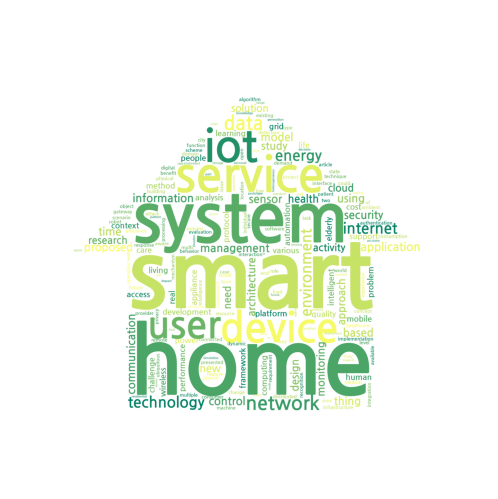

In [68]:
tfidf = tfidf_matrix
tfidf_array = tfidf.toarray()

tfidf_means = np.mean(tfidf_array, axis=0).reshape(-1, 1)
cosine_sim = cosine_similarity(tfidf_array.T)
cosine_means = np.mean(cosine_sim, axis=0).reshape(-1, 1)

centroid_features = np.mean(tfidf_array.T, axis=0)
cosine_similarities = cosine_similarity(tfidf_array.T, centroid_features.reshape(1, -1))

dot_product = tfidf_array.T.dot(tfidf_array)
dot_product_means = np.mean(dot_product, axis=0).reshape(-1, 1)

lda_model = LatentDirichletAllocation(n_components=1)
lda_model.fit(tfidf_array)
lda_scores = lda_model.components_[0].reshape(-1, 1)

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(np.hstack([tfidf_means, cosine_means, cosine_similarities, dot_product_means, lda_scores]))

keyword_values = np.sum(scaled_values, axis=1)

if np.isnan(keyword_values).any():
    keyword_values = np.nan_to_num(keyword_values)

palettes = ['spring', 'summer', 'seismic','PuBu']

# 워드 클라우드 그리기
wordcloud = WordCloud(background_color ='White',
                      mode="RGB",
                      mask = shs_mask,
                      colormap='summer',
                      width = 800,
                      height = 800,
                      font_path=path,
                      scale=7,stopwords = stop_words).generate_from_frequencies(dict(zip(vectorizer.get_feature_names_out(), keyword_values)))

plt.axis('off')
plt.tight_layout(pad=0)
plt.imshow(wordcloud, interpolation='antialiased')
plt.show()

## STEP 3 : Unsupervised machine learning

In [70]:
# 윗 단계 생략
core_keywords = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/core_keyword.csv")
core_keywords = list(core_keywords['keyword'])

In [ ]:
# 차원 축소 코드 - 해당 과정 일단 생략
# X = tfidf_matrix

# svd = TruncatedSVD(n_components=X.shape[1]-1)
# svd.fit(X)

# cumulative_explained_variance = np.cumsum(svd.explained_variance_ratio_)

# n_components = np.where(cumulative_explained_variance > 0.95)[0][0]

# print(f"Number of components for 95% variance: {n_components}")

# plt.plot(cumulative_explained_variance)
# plt.xlabel('Number of components')
# plt.ylabel('Cumulative explained variance')
# plt.axvline(x=n_components, color='r', linestyle='--', label=f'Components={n_components}')
# plt.legend()
# plt.show()

In [81]:
for word in core_keywords:
  if type(word) == float:
      print(core_keywords.index(word))

hi
449
nan


In [86]:
del core_keywords[449]

In [87]:
vectorizer = TfidfVectorizer(vocabulary=core_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

### Spectral Clustering

In [88]:
metrics = ['cosine', 'euclidean']
cluster_range = range(2, 41)

results = {}

for metric in metrics:
    results[metric] = []

    if metric == 'cosine':
        affinity = 'precomputed'
        sim_matrix = cosine_similarity(tfidf_matrix)

    elif metric == 'euclidean':
        affinity = 'precomputed'
        distance_matrix = euclidean_distances(tfidf_matrix)
        sigma = np.mean(distance_matrix)
        sim_matrix = np.exp(-distance_matrix ** 2 / (2.0 * ( sigma ** 2)))

    for n_clusters in cluster_range:
        silhouette_avg_list = []

        # Spectral Clustering
        for _ in range(10):
            sc = SpectralClustering(n_clusters=n_clusters, affinity = affinity).fit(sim_matrix)
            labels=sc.labels_

            silhouette_avg_list.append(silhouette_score(sim_matrix, labels, metric = metric))

        results[metric].append(np.mean(silhouette_avg_list))

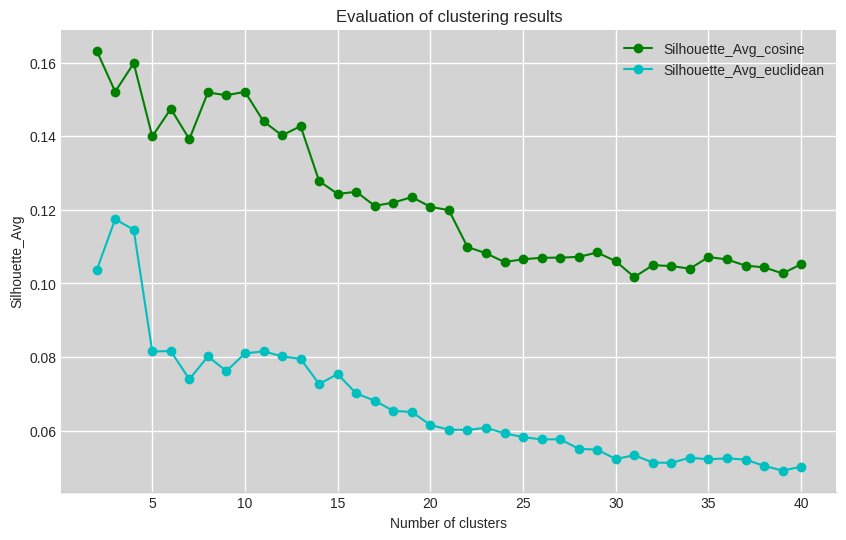

In [89]:
# spectral clustering 결과
plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(10,6))

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.gca().set_facecolor('lightgray')
plt.grid(color='white', linestyle='-', linewidth=1)

for metric in metrics:

    if metric == 'cosine':
        color = 'g'
    elif metric == 'euclidean':
        color = 'c'

    plt.plot(cluster_range, results[metric], label=f'Silhouette_Avg_{metric}', marker='o', color = color)

plt.title('Evaluation of clustering results')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette_Avg')
plt.legend()
plt.show()

## STEP 4 : Topic Modeling : Interpreting the clusters

### Topic modeling(NMF & LDA)

In [94]:
n_clusters = 13
n_topics = 1
n_top_words = 20

vectorizer = TfidfVectorizer(vocabulary=core_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

sim_matrix = cosine_similarity(tfidf_matrix)

clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42).fit(sim_matrix)
labels = clustering.labels_

nmf = NMF(n_components=n_topics, random_state=0)
lda = LatentDirichletAllocation(n_components=n_topics, random_state=0)

result_df = pd.DataFrame()
cluster_counts = Counter(labels)

for cluster, count in sorted(cluster_counts.items(), key=lambda x: x[0]):
    print(f"클러스터 {cluster}: {count}개의 문서")

for i in range(n_clusters):
    cluster_data = tfidf_matrix[labels == i]

    nmf.fit(cluster_data)
    nmf_topic_words = nmf.components_.argsort()[:, ::-1]
    nmf_topics = [vectorizer.get_feature_names_out()[index] for index in nmf_topic_words[0, :n_top_words]]

    lda.fit(cluster_data)
    lda_topic_words = lda.components_.argsort()[:, ::-1]
    lda_topics = [vectorizer.get_feature_names_out()[index] for index in lda_topic_words[0, :n_top_words]]

    for nmf_topic, lda_topic in zip(nmf_topics, lda_topics):
        result_df = result_df.append({'Cluster': i, 'NMF_Topic': nmf_topic, 'LDA_Topic': lda_topic}, ignore_index=True)

# 클러스터 중심 계산
cluster_centers = defaultdict(list)
for label, tfidf in zip(labels, tfidf_matrix):
    cluster_centers[label].append(tfidf.toarray())
for label, tfidfs in cluster_centers.items():
    cluster_centers[label] = np.mean(tfidfs, axis=0)

# 상위 문서 계산
top_docs = defaultdict(list)

for label, tfidf, title in zip(labels, tfidf_matrix, df['Article Title']):
    similarity = cosine_similarity(cluster_centers[label].reshape(1, -1), tfidf.toarray())
    top_docs[label].append((title, similarity[0,0]))

for label, docs in top_docs.items():
    top_docs[label] = sorted(docs, key=lambda x: x[1], reverse=True)[:5]

for label, docs in top_docs.items():
    for doc, similarity in docs:
        result_df = result_df.append({'Cluster': label, 'Top_Doc': doc, 'Similarity': similarity}, ignore_index=True)

writer = pd.ExcelWriter('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/final_result.xlsx', engine='xlsxwriter')

result_df.to_excel(writer, sheet_name='Topic_Modeling', index=False)

for label, docs in top_docs.items():
    df_temp = pd.DataFrame(docs, columns=['Article title', 'Similarity'])
    df_temp.to_excel(writer, sheet_name=f'Cluster_{label}_Top_Docs', index=False)

writer.save()

클러스터 0: 309개의 문서
클러스터 1: 138개의 문서
클러스터 2: 336개의 문서
클러스터 3: 861개의 문서
클러스터 4: 195개의 문서
클러스터 5: 168개의 문서
클러스터 6: 273개의 문서
클러스터 7: 104개의 문서
클러스터 8: 190개의 문서
클러스터 9: 204개의 문서
클러스터 10: 315개의 문서
클러스터 11: 504개의 문서
클러스터 12: 236개의 문서


In [ ]:
# kbest_chi2 = SelectKBest(score_func=chi2, k=100)
# kbest_chi2.fit(tfidf_matrix, labels)
# word_features_chi2 = np.array(kbest_chi2.get_support(indices=True))

# kbest_f = SelectKBest(score_func=f_classif, k=100)
# kbest_f.fit(tfidf_matrix, labels)
# word_features_f = np.array(kbest_f.get_support(indices=True))

# word_features = set(word_features_chi2) & set(word_features_f)

# feature_names = vectorizer.get_feature_names_out()
# keywords = []

# for feature_index in word_features:
#     keywords.append(feature_names[feature_index])

# temp_df = pd.DataFrame(keywords, columns=['keyword'])
# temp_df.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/simple_analysis(chi2 & F-values).csv', index = False)


### Visualization(Longabaugh, 2012)

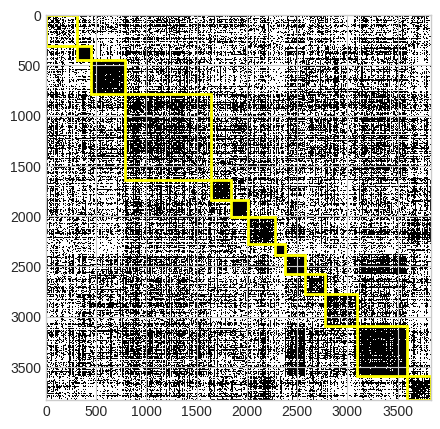

In [95]:
import networkx as nx
from matplotlib import pyplot, patches

cos_sim = cosine_similarity(tfidf_matrix)
mean_sim = np.mean(cos_sim)
threshold = mean_sim * 0.8
binary_adj_matrix = np.where(cos_sim >= threshold, 1, 0)

node_order = np.argsort(labels)
sorted_binary_adj_matrix = binary_adj_matrix[node_order, :][:, node_order]

def draw_adjacency_matrix(G, node_order=None, partitions=[], colors=[]):
    """
    - G is a netorkx graph
    - node_order (optional) is a list of nodes, where each node in G
          appears exactly once
    - partitions is a list of node lists, where each node in G appears
          in exactly one node list
    - colors is a list of strings indicating what color each
          partition should be
    If partitions is specified, the same number of colors needs to be
    specified.
    """
    adjacency_matrix = nx.to_numpy_array(G, dtype=np.bool, nodelist=node_order)

    #Plot adjacency matrix in toned-down black and white
    fig = pyplot.figure(figsize=(5, 5)) # in inches
    pyplot.imshow(adjacency_matrix,
                  cmap="Greys",
                  interpolation="none")

    # The rest is just if you have sorted nodes by a partition and want to
    # highlight the module boundaries
    assert len(partitions) == len(colors)
    ax = pyplot.gca()
    current_idx = 0
    for partition, color in zip(partitions, colors):
        ax.add_patch(patches.Rectangle((current_idx, current_idx),
                                          len(partition), # Width
                                          len(partition), # Height
                                          facecolor="none",
                                          edgecolor=color,
                                          linewidth=2))
        current_idx += len(partition)

G = nx.from_numpy_array(sorted_binary_adj_matrix)

partitions = []
for i in range(n_clusters):
    partitions.append([idx for idx, cluster in enumerate(labels) if cluster == i])

colors = ['#FFFF00' for _ in range(n_clusters)]
draw_adjacency_matrix(G, partitions=partitions, colors=colors)

### Network analysis

TypeError: ColormapRegistry.get_cmap() takes 2 positional arguments but 3 were given

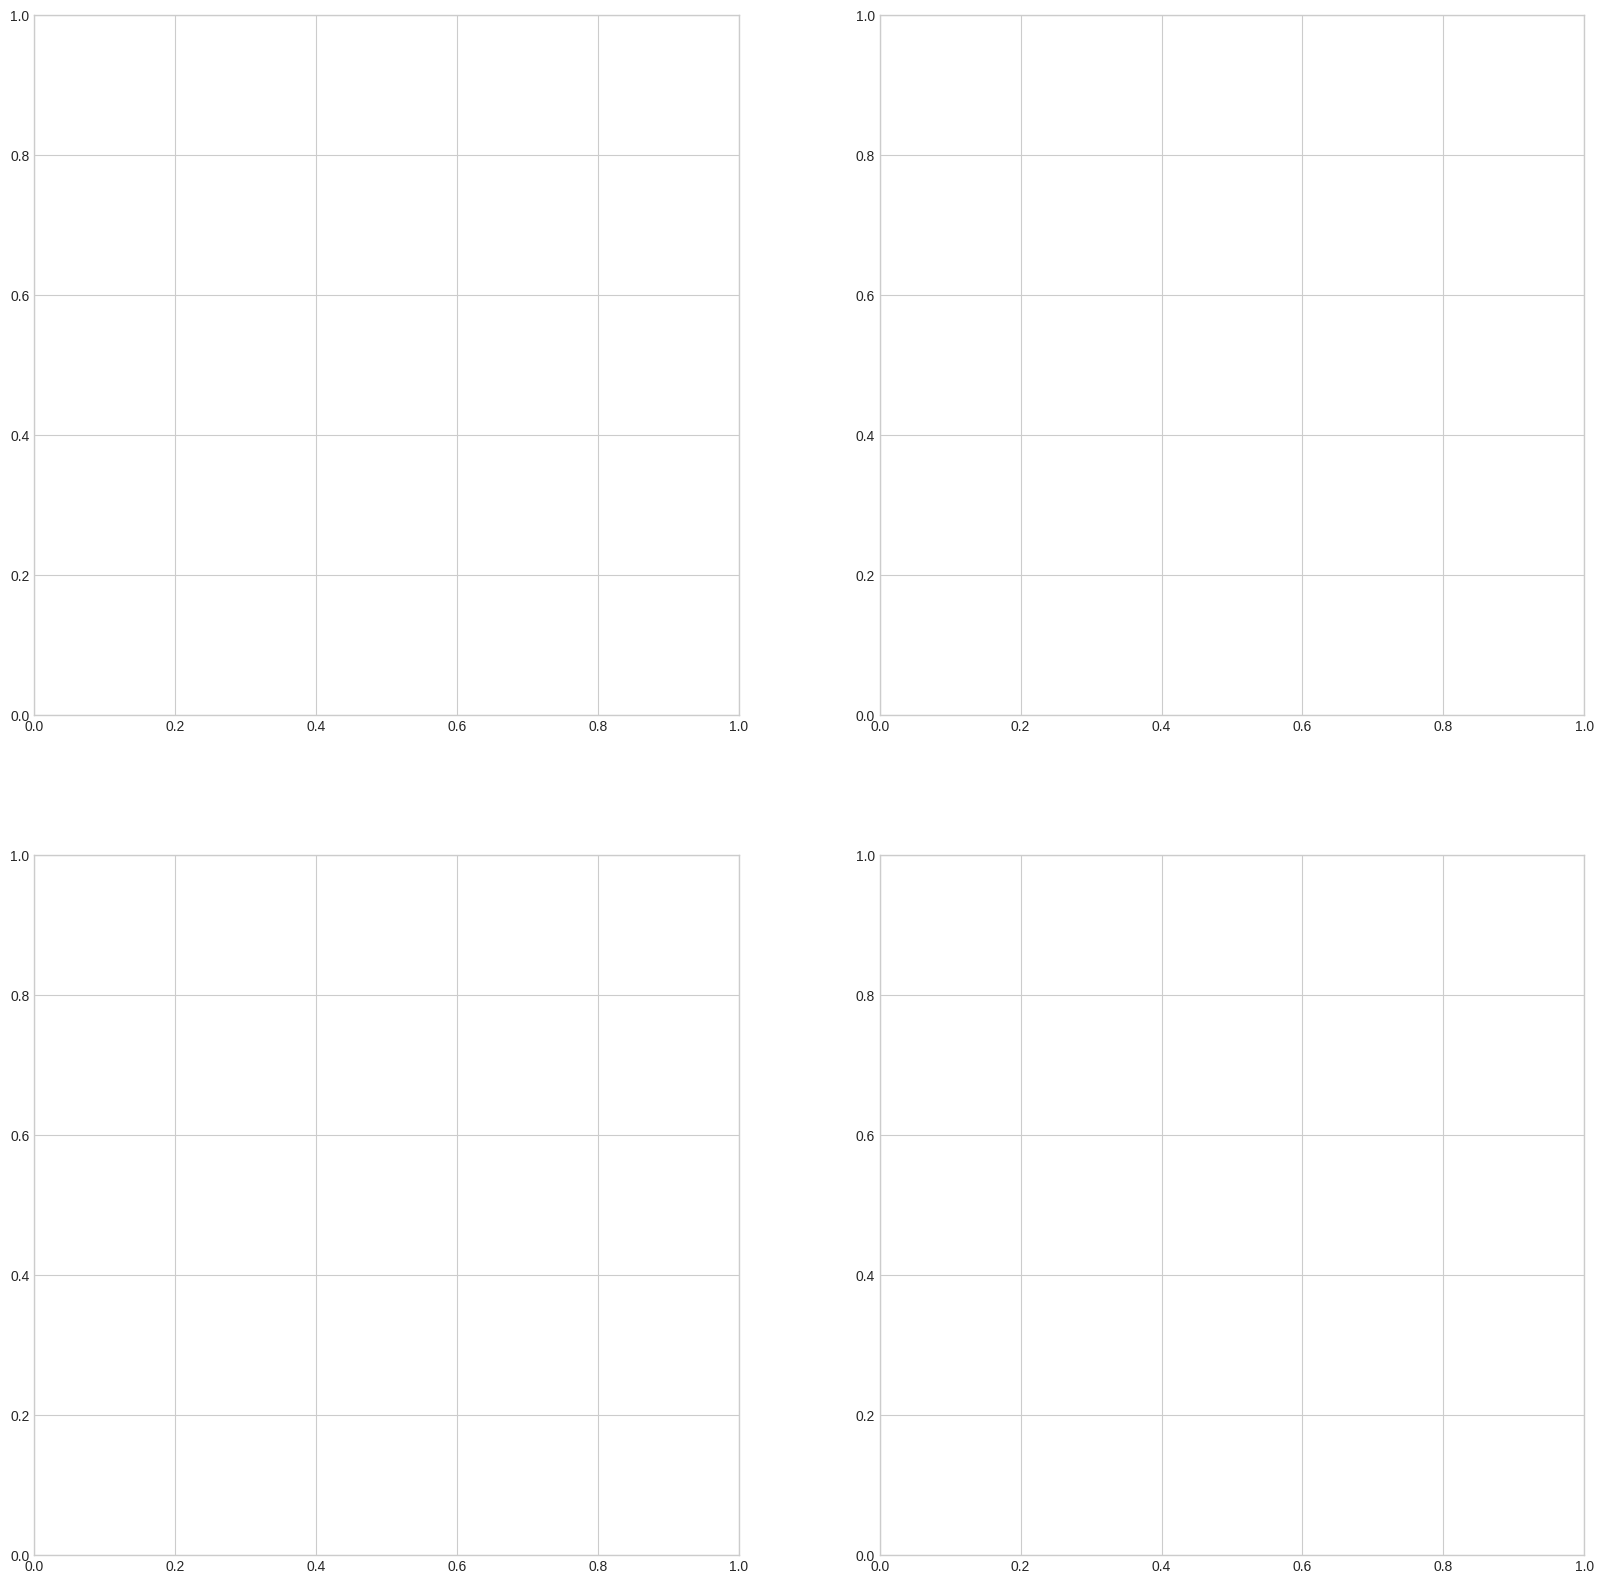

In [97]:
## 필요한 라이브러리 임포트
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib import colormaps

## 클러스터 중심점 계산
centroids = np.array([np.mean(tfidf_matrix[clustering.labels_ == i].toarray(), axis=0) for i in range(n_clusters)])

## 클러스터 간 유사도 계산
similarity_matrix = cosine_similarity(centroids)

## 각 클러스터에서 가장 유사한 3개의 클러스터 찾기
top_clusters = {i: sorted(range(len(similarity_matrix[i])), key=similarity_matrix[i].__getitem__, reverse=True)[1:4] for i in range(n_clusters)}

## 그래프 생성
G = nx.Graph()
for cluster, neighbors in top_clusters.items():
    for neighbor in neighbors:
        G.add_edge(cluster, neighbor)

## 그래프 그리기
fig, axs = plt.subplots(2, 2, figsize=(20,20))

## 노드 크기 설정 (노드의 차수에 비례하되, 전체적으로 크기를 키움)
sizes = [G.degree(node) * 1000 for node in G]  # 노드 크기를 기존보다 더 크게 조절

## 노드 중요성 계산 (degree로 가정)
importance = [G.degree(node) for node in G]

## 노드 색상 설정 (중요성에 따른 색상 조절, 중요도가 클수록 색상이 진해짐)
cmap = colormaps.get_cmap('Greens', max(importance)-min(importance)+1) # 컬러맵을 'Blues'로 설정
node_colors = [cmap(i-min(importance)) for i in importance]

## 그래프 레이아웃 설정 및 그래프 그리기
layouts = [nx.spring_layout, nx.circular_layout, nx.random_layout, nx.shell_layout]
titles = ['Spring Layout', 'Circular Layout', 'Random Layout', 'Shell Layout']

for i, ax in enumerate(axs.flatten()):
    pos = layouts[i](G)
    nx.draw(G, pos, with_labels=True, node_size=sizes, node_color=node_colors, edgecolors='black', font_size=8, font_weight='bold', ax=ax)
    ax.set_title(titles[i], fontsize=16, fontweight='bold')

## 그래프 출력
plt.show()